# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [ ]:
# !pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 29.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=de092152a24af33d6775edcdfdf97d4cb701ae926bf122c91e558e1e8d635b86
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# import nltk
# from nltk.corpus import stopwords
# nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

***

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## <font color=#05C0F3>**Datos de reviews de amazon**</font>

In [ ]:
print('Train')
train_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/train.jsonl"
train_df = pd.read_json(train_url, lines=True)
display(train_df)

print("\n" + "-" * 80 + "\n")

print('Test')
test_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/test.jsonl"
test_df = pd.read_json(test_url, lines=True)
display(test_df)

print("\n" + "-" * 80 + "\n")

print('Validation')
val_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/validation.jsonl"
val_df = pd.read_json(val_url, lines=True)
display(val_df)

Train


,id,text,label,label_text
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,0
3,es_0359921,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,0
...,...,...,...,...
199995,es_0715276,Tal y como se describe\n\nMando funciona perfe...,4,4
199996,es_0085190,Funciona perfectamente\n\nCompré la batería co...,4,4
199997,es_0484496,Buena calidad.\n\nBuena calidad. Satisfecha co...,4,4
199998,es_0930141,Recomendado\n\nPerfecto para el cumple de mi hijo,4,4



--------------------------------------------------------------------------------

Test


,id,text,label,label_text
0,es_0038754,no me llego\n\nno me llego el articulo me lo m...,0,0
1,es_0748979,amazon sigue sin cumplir en las entregas\n\nla...,0,0
2,es_0411746,ESTAFA EN EL ENVÍO\n\nEstoy muy decepcionado c...,0,0
3,es_0786686,Estafa de Amazon\n\nMi valoración no es sobre ...,0,0
4,es_0429700,No conseguí pasar de la portada en Kindle\n\nP...,0,0
...,...,...,...,...
4995,es_0685611,Perfectos para lo que sirven\n\nPara lo que cu...,4,4
4996,es_0638242,"Buen vendedor, rápido y fiable.\n\nMaterial mu...",4,4
4997,es_0760108,medallas con bonito grabado\n\nSe ve bien el g...,4,4
4998,es_0070806,timbre\n\nlo compré para mi bici pero finalmen...,4,4



--------------------------------------------------------------------------------

Validation


,id,text,label,label_text
0,es_0417480,"Mala compra\n\nMalisimo, muy grande demasiado ...",0,0
1,es_0180432,No lo he recibido\n\nNo he recibido el pedido ...,0,0
2,es_0144850,Que no aprieta bien en el manillar\n\nTengo qu...,0,0
3,es_0339629,Brocas de mantequilla\n\nUtilicé las brocas de...,0,0
4,es_0858362,No me gusta\n\nNo me gusta su olor a viejo y a...,0,0
...,...,...,...,...
4995,es_0179515,guadalupe\n\nMe ha encantado la cesta. Ha lleg...,4,4
4996,es_0894902,calidad precio\n\nDesempeña su función correct...,4,4
4997,es_0760496,Excelente\n\nMe ha encantado la diadema! Las f...,4,4
4998,es_0178380,"Genial\n\nA mi me gustan mucho las fundas TPU,...",4,4


In [ ]:
train_df = train_df[['text', 'label']]
test_df = test_df[['text', 'label']]
val_df = val_df[['text', 'label']]

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [ ]:
print('Train')
display(train_df.head(10))

print("\n" + "-" * 80 + "\n")

print('Test')
display(test_df.head(10))

print("\n" + "-" * 80 + "\n")

print('Validation')
display(val_df.head(10))

Train


,text,label
0,television Nevir\n\nNada bueno se me fue ka pa...,0
1,Dinero tirado a la basura con esta compra\n\nH...,0
2,solo llega una unidad cuando te obligan a comp...,0
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0
4,Devuelto\n\nLlega tarde y co la talla equivocada,0
5,Jamás me llegó\n\nJamás me llegó y el vendedor...,0
6,Horroroso!!!\n\nEl paraguas es de muy mala cal...,0
7,Poco funcional\n\nTuve que devolverla porque a...,0
8,No me llego\n\nEstoy esperando despues de prot...,0
9,"Mala calidad, defectuoso\n\nDefectuoso. En apa...",0



--------------------------------------------------------------------------------

Test


,text,label
0,no me llego\n\nno me llego el articulo me lo m...,0
1,amazon sigue sin cumplir en las entregas\n\nla...,0
2,ESTAFA EN EL ENVÍO\n\nEstoy muy decepcionado c...,0
3,Estafa de Amazon\n\nMi valoración no es sobre ...,0
4,No conseguí pasar de la portada en Kindle\n\nP...,0
5,Una verdadera pena\n\nCompre este teclado al v...,0
6,No compréis es un engaño\n\nSigue sin llegar d...,0
7,"No sirve para nada, pésimo producto\n\nNo sirv...",0
8,Pésimo trato del vendedor\n\nTodavía espero qu...,0
9,Pésima camara\n\nLa peor cámara que he tenido ...,0



--------------------------------------------------------------------------------

Validation


,text,label
0,"Mala compra\n\nMalisimo, muy grande demasiado ...",0
1,No lo he recibido\n\nNo he recibido el pedido ...,0
2,Que no aprieta bien en el manillar\n\nTengo qu...,0
3,Brocas de mantequilla\n\nUtilicé las brocas de...,0
4,No me gusta\n\nNo me gusta su olor a viejo y a...,0
5,"Bolas rotas\n\nHola, después de recoger el paq...",0
6,A parte de no poder elegir color...\n\nA parte...,0
7,Tapa pantalla\n\nMuy baja calidad de ahí si pr...,0
8,NO HE RECIBIDO EL PRODUCTO\n\nEl producto sale...,0
9,"Una patata.\n\nNo lo recomiendo, no se pega y ...",0


In [ ]:
print('Train')
display(train_df.tail(10))

print("\n" + "-" * 80 + "\n")

print('Test')
display(test_df.tail(10))

print("\n" + "-" * 80 + "\n")

print('Validation')
display(val_df.head(10))

Train


,text,label
199990,Julio\n\nMuy bueno y materiales muy bien. Faci...,4
199991,Muy cómodo!\n\nMi gato pesa 5 kg y entra perfe...,4
199992,"Muy bien\n\nMuy buen producto , juego muy dive...",4
199993,La droga +dura 2\n\nSi la primera parte me gus...,4
199994,Precio\n\nFuncional. Buena calidad/precio.,4
199995,Tal y como se describe\n\nMando funciona perfe...,4
199996,Funciona perfectamente\n\nCompré la batería co...,4
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,4
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,4
199999,Preciosas\n\nSúper bien! Las brochas son buena...,4



--------------------------------------------------------------------------------

Test


,text,label
4990,buen producto\n\npedi una talla mas porque hab...,4
4991,Dinámico para bebes\n\nMuy didáctico y es tal ...,4
4992,Medias\n\nLas mejores medias que he tenido y l...,4
4993,Genial para no mojarse las manos\n\nEs genial ...,4
4994,producto barato y cumple con sus funciones\n\n...,4
4995,Perfectos para lo que sirven\n\nPara lo que cu...,4
4996,"Buen vendedor, rápido y fiable.\n\nMaterial mu...",4
4997,medallas con bonito grabado\n\nSe ve bien el g...,4
4998,timbre\n\nlo compré para mi bici pero finalmen...,4
4999,Auriculares sin cables de verdad\n\nPues este ...,4



--------------------------------------------------------------------------------

Validation


,text,label
0,"Mala compra\n\nMalisimo, muy grande demasiado ...",0
1,No lo he recibido\n\nNo he recibido el pedido ...,0
2,Que no aprieta bien en el manillar\n\nTengo qu...,0
3,Brocas de mantequilla\n\nUtilicé las brocas de...,0
4,No me gusta\n\nNo me gusta su olor a viejo y a...,0
5,"Bolas rotas\n\nHola, después de recoger el paq...",0
6,A parte de no poder elegir color...\n\nA parte...,0
7,Tapa pantalla\n\nMuy baja calidad de ahí si pr...,0
8,NO HE RECIBIDO EL PRODUCTO\n\nEl producto sale...,0
9,"Una patata.\n\nNo lo recomiendo, no se pega y ...",0


In [ ]:
print('Train')
display(train_df.sample(10))


Train


,text,label
105595,Adri\n\nEl funko ha llegado en perfectas condi...,2
111016,Justo lo que es\n\nBuena calidad precio,2
53248,Afilar\n\nNo me gusta porque no afila las tije...,1
46285,No funciona mando\n\nNo funciona el mando de c...,1
169749,"Calidad\n\nMarca de confianza, buena calidad d...",4
6485,No he recibido el pedido completo. ¿Dónde pued...,0
59451,DEMASIADO SUPERFICIAL\n\nEsperaba un contenido...,1
40137,Fiambre tierno no\n\nEl fiambre tierno lo dest...,1
30386,abrazadera de acelerador de moto\n\nel articul...,0
120946,Me ha gustado mucho\n\nÉsta colección es una d...,3


In [ ]:
print('Test')
display(test_df.sample(10))

Test


,text,label
3115,BUEN PRODUCTO\n\nES UN PRODUCTO DE BUENA CALID...,3
4300,Tiene una capacidad muy buena para almacenar d...,4
4970,Buen precio y producto bien protegido.\n\nLa c...,4
3508,"Sonido\n\nEstan super bien, lo unico que uno s...",3
2856,Pequeño pero matón.\n\nBuenos materiales. Gran...,2
3454,Bastante bien\n\nNo me doy las 5 estrellas por...,3
1612,No coincide con el modelo\n\nEl producto es bu...,1
2036,Cumple su función\n\nGafas que por el precio q...,2
4110,"Muy buena compra\n\nMuy sencillo en su manejo,...",4
627,yo\n\nLo tuve q devolver incluso antes de habe...,0


In [ ]:
print('Validation')
display(val_df.sample(10))

Validation


,text,label
4687,Buen soporte\n\nEstabilidad buena y está basta...,4
4337,justo lo que necesitaba\n\nmantiene el agua fr...,4
1448,Me ha durado 1 año\n\nEl aspecto y construcció...,1
4413,"Perfecto\n\nPerfecto, ha hecho el suelo y el a...",4
2758,bien\n\nya es el segundo que compro y hasta ah...,2
4293,Servicio rápido y bueno\n\nMe gusta como funda...,4
2409,Funda resistente\n\nLa funda es muy resistente...,2
757,dificultad de montaje\n\npara poderlo colocar ...,0
241,Mala compra\n\nDos años y ya no funciona.....m...,0
1416,"Español latino\n\nCuidado con la traducción, e...",1


### **Verificación de Dimensiones y Tipos**

In [ ]:
print(f'Los datos de entrenamiento tienen {train_df.shape[0]} filas y {train_df.shape[1]} columnas.')
print(f'Los datos de prueba tienen {test_df.shape[0]} filas y {test_df.shape[1]} columnas.')
print(f'Los datos de validacion tienen {val_df.shape[0]} filas y {val_df.shape[1]} columnas.')

Los datos de entrenamiento tienen 200000 filas y 2 columnas.
Los datos de prueba tienen 5000 filas y 2 columnas.
Los datos de validacion tienen 5000 filas y 2 columnas.


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    200000 non-null  object
 1   label   200000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [ ]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


### **Eliminando duplicados**

In [ ]:
display(train_df.shape)
display(test_df.shape)
display(val_df.shape)

(200000, 2)

(5000, 2)

(5000, 2)

In [ ]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()
val_df = val_df.drop_duplicates()

In [ ]:
display(train_df.shape)
display(test_df.shape)
display(val_df.shape)

(199795, 2)

(5000, 2)

(5000, 2)

In [ ]:
200000 - 199795

205

Se eliminan *205* duplicados

### **Longitud de los textos**

In [ ]:
for i in [train_df, test_df, val_df]:
  display(i.describe())

,label
count,199795.000000
mean,1.999520
std,1.414167
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


,label
count,5000.000000
mean,2.000000
std,1.414355
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


,label
count,5000.000000
mean,2.000000
std,1.414355
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [ ]:
for i in [train_df, test_df, val_df]:
  display(i['text'].describe())


,text
count,199795
unique,199726
top,Calidad precio correcto\n\nCalidad precio corr...
freq,3


,text
count,5000
unique,5000
top,Auriculares sin cables de verdad\n\nPues este ...
freq,1


,text
count,5000
unique,5000
top,Buena calidad\n\nEl artículo ha cumplido con l...
freq,1


In [ ]:
train_df['n_palabras'] = train_df['text'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
test_df['n_palabras'] = test_df['text'].str.split().str.len()
val_df['n_palabras'] = val_df['text'].str.split().str.len()

In [ ]:
train_df['n_palabras'].describe()

,n_palabras
count,199795.000000
mean,31.136100
std,24.820879
min,3.000000
25%,16.000000
50%,25.000000
75%,38.000000
max,566.000000


#### Longitud extrema: análisis más profundo de outliers

In [ ]:
train_df['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,59.0
0.95,76.0
0.99,127.0


In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
train_df.loc[train_df['n_palabras'] > 127, 'text'].sample(1)

,text
151405,"Buen pack, mal hornillo\n\nEste pack está muy bien pensado. La olla grande y la cacerola pequeña tienen un tamaño muy bueno, es fácilmente transportable y evita tener que llevar ninguna vajilla adicional para excursiones de una sola persona. El vaso no creo que lo use, pero tiene buena pinta. Los cubiertos están muy bien. Son muy pequeños y ligeros, pero perfectamente funcionales. El cuchillo es muy justito, pero como siempre llevo una navaja adicional, eso no es un problema. Las patitas para dar equilibrio a la bombona de gas están también muy bien. El hornillo es bastante malillo. No me ha funcionado nunca el encendido piezo eléctrico y una de las patitas queda un poco más baja que las demás, quedando la olla un poco coja. No he reclamado porque el precio del conjunto es imbatible y no quiero mandarlo todo de vuelta solo por el hornillo. Si necesito otro, ya me lo compraré aparte."


In [ ]:
train_df[['text', 'n_palabras']].query('n_palabras > 127').sample(10)

,text,n_palabras
105456,"Agradable olor - empresa poco seria\n\nLa verdad, estoy contento con este producto. El aceite deja la barba suave y definida y ayuda a poder peinarla como quieras. El estuche en el que viene es muy chulo y tienes variedad de fragancias. El olor de los diferentes aceites es muy agradable y tienes variedad. Como único pequeño punto negativo, tal vez resaltaria que el olor no es muy duradero, en unas horas desaparece casi por completo. EDITADO: Cuando compras este producto, la empresa fabricante se pone en contacto contigo para animarte a hacer una buena critica del producto, ofreciendote muestras gratuitas de una nueva gama de aceite. Las muestras gratuitas nunca te las envian y me parece una tactica un tanto cutre y de tomar por tontos a sus clientes para intentar animarte a poner un buen comentario sobre su producto.",141
59039,"luces y sombras\n\nEs casi imposible montarla, aunque la metas al microondas o la pongas a hervir en agua. A mí me tocó llevarla al mecánico porque fui incapaz, ya que está muy dura. En cuanto al manejo del patinete con este neumático, es horrible. Es una rueda muy recta, con la que casi no se puede tumbar o te vas al suelo. Recomiendo comprar otra con más curva. La amortiguación que se pierde con respecto a las ruedas hinchables es considerable, de modo que si vas por baches te tiembla todo el cuerpo. Ahora bien, después de pinchar 5 veces en un mes, el hecho de no tener que reparar de nuevo los pinchazos, a mí me lo compensa. Tal vez sea buena idea comprar unas cámaras más resistentes (de más grosor). Tengo que decir que yo llevaba antes las ruedas de 10"", que son una maravilla en cuanto a la sensación de conducción. Eso sí, la vida de la batería es un poco más larga ahora, con estas ruedas.",171
169139,"Fácil de utilizar hasta para un/a novato/a.\n\nLa regale y a la persona a quien le hice el regalo no sabía ni que era, pero a los dos días está encantada con su nuevo juguete, lo único que le costó localizar es como utilizar la presión arterial, en una respuesta de otro cliente encontramos la solución, no aparece el icono en el menú de interfaces, pera lograr la medida hay que hacerlo con el reloj puesto y desde el móvil, una vez puesto el reloj se da al icono que aparece en la aplicación y te toma la lectura y la deja apuntada en el mismo móvil, esto es no aparece el icono de presión arterial hasta que no haces desde el movíl que se active. Por lo demás es ligero, no molesta al tenerlo puesto, la recarga es comoda ya que es a través de USB, por ahora está muy contenta.",152
72216,"Pocas páginas, poca letra...poco atractivo\n\nEl libro me llegó con una página estropeada pero amazon tuvo una respuesta genial, en dos días tenía un nuevo libro en mi casa (tiene los cantos estropeados pero por dentro está bien) por lo que la puntuación no es por eso. Compré este libro dejándome llevar por los comentarios y quedé sorprendida, nada que ver los comentarios con el libro recibido...no es una caja con un libro dentro de tapa blanda, ni lleva accesorios de ningún tipo ni tiene una trama sorprendente...es un libro de tapa dura, con poca letra y con sonido, le das a un botón y grita, no hay más que eso. Yo no lo volvería a comprar, por el mismo precio se pueden encontrar en amazon productos de mejor calidad y más entretenidos.",133
72007,"No recomendable\n\nLas dos estrellas que le doy solo tienen una razón, su diseño. Es diferente, juvenil y lo que buscaba. Quejas muchas. Llegó con un piquete en la esquina derecha, espejo del lateral derecho parte superior rayado. Y la calidad deja mucho que desear. Solo terminado de montar y limpiarlo ya se veían desperfectos y al menos roce parece de papel. Por su precio nada recomendable, por su baja calidad ha perdido de ser un buen producto ya que tratándose de diseño es complicado encontrar algo así. Soy sincera y aun teniendo mucho cuidado se estropeará fijo. Me planteo devolverlo, solo que después del montaje que no es complejo pero si tiene muc

In [ ]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [ ]:
train_df['label'].value_counts()

,count
label,
1,39986
0,39967
2,39960
4,39942
3,39940


In [ ]:
train_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.200135
0,0.200040
2,0.200005
4,0.199915
3,0.199905


In [ ]:
train_df.sample(10)

,text,label,n_palabras
117994,"muy cómodo y pliega bien, solo que\n\ncompré d...",2,41
34323,"Esperando\n\nNo me llegado, aunque ponga que y...",0,10
110417,Bonito pero muy bajo\n\nDemasiado bajo aunque ...,2,13
107584,"No sé cuándo lo compre, no recuerdo haberlo co...",2,34
107747,"Barata\n\nPor lo que vale , no está mal.",2,9
46885,Pequeño y enclenque\n\nSólo para muñecas peque...,1,13
77373,Sólo sirve para mandos muy ligeros\n\nSe vence...,1,22
12205,"bolas\n\nmuy pequeñas y alguna a venido rota ,...",0,31
121432,"Rasca?\n\nHola, lo acabo de comprar. Las prime...",3,26
68610,"Básico\n\nPor 17€ no se puede pedir más, pero ...",1,46


In [ ]:
def map_sentiment(stars):
    if stars <= 2:
        return "Negativo"
    elif stars == 3:
        return "Neutro"
    else:
        return "Positivo"

train_df["label"] = train_df["label"].apply(map_sentiment)
test_df["label"] = test_df["label"].apply(map_sentiment)
val_df["label"] = val_df["label"].apply(map_sentiment)

### **Graficos**

In [ ]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [ ]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [ ]:
color_primario   = "#05C0F3"  # Azul
color_secundario = "#F90499"  # Magenta
color_terciario  = "#2ECC71"  # Verde
color_cuarto     = "#F1C40F"  # Amarillo
color_quinto     = "#E74C3C"  # Rojo

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

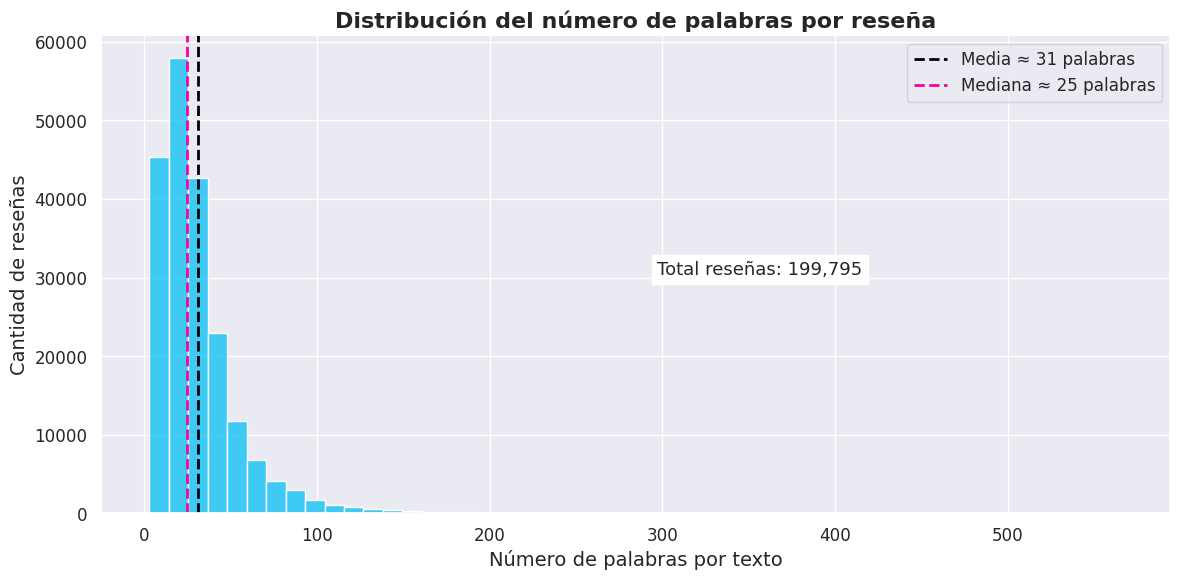

In [ ]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      train_df['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = train_df['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  plt.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label = f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(train_df):,}",
      fontsize = 13,
      bbox=dict(facecolor = "white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

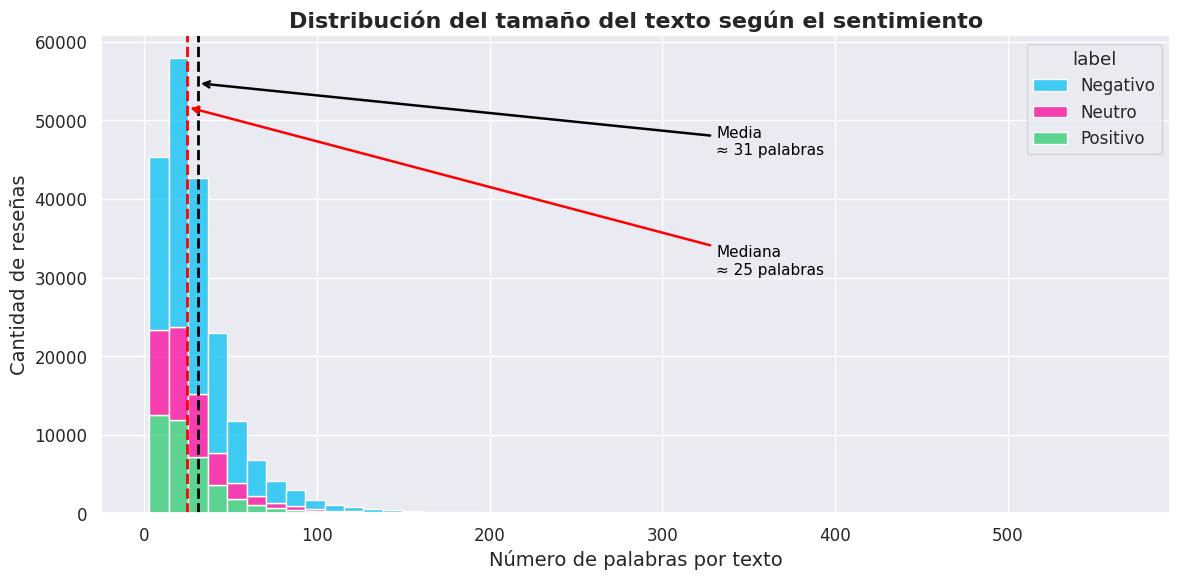

In [ ]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = train_df,
      x = 'n_palabras',
      hue = 'label',
      palette = [color_primario, color_secundario, color_terciario],
      bins=50,
      multiple = "stack"
      )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = train_df['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  ax.axvline(
      mediana,
      color = 'red',
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'red',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

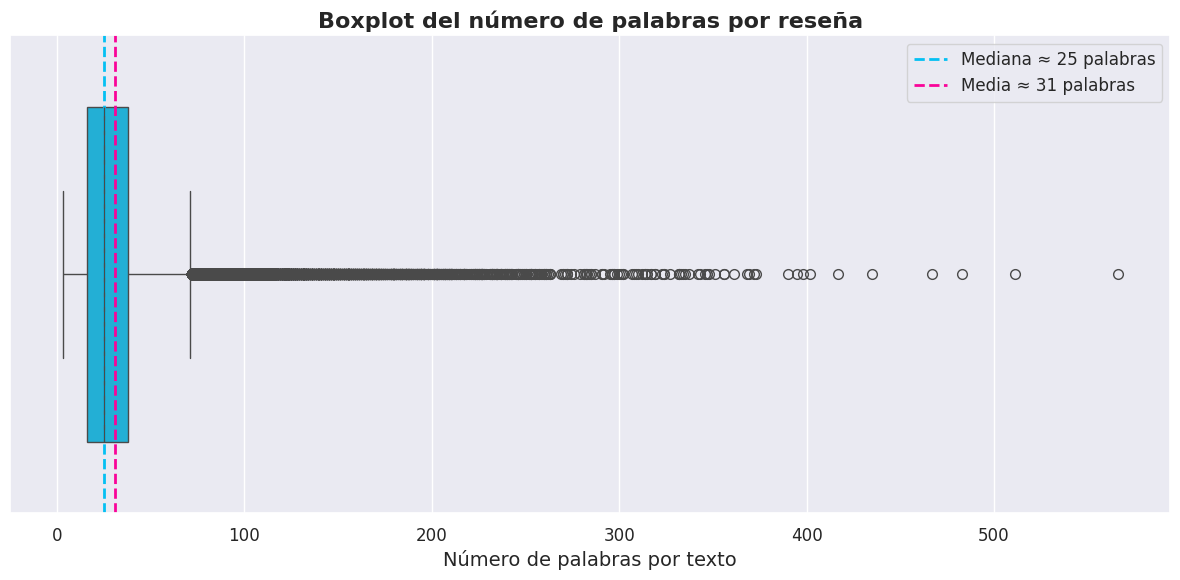

In [ ]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = train_df['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = train_df['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

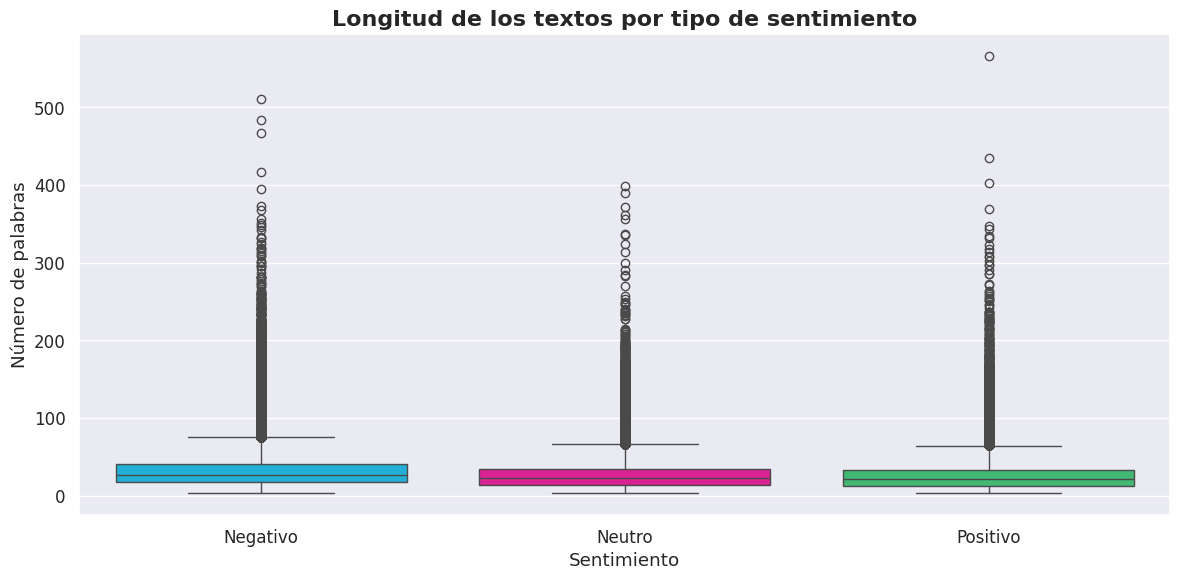

In [ ]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = train_df,
      x='label',
      y = 'n_palabras',
      hue = 'label',
      palette = [color_primario, color_secundario, color_terciario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

- El conjunto de datos presenta una estructura clara y consistente, compuesta principalmente por dos columnas relevantes para el modelado: el texto de la reseña y su respectiva etiqueta de sentimiento. Tras el proceso de limpieza, se eliminaron 205 registros duplicados, una cantidad mínima en comparación con el tamaño total del conjunto de entrenamiento (casi 200 000 observaciones), lo que confirma una alta calidad inicial de los datos y reduce el riesgo de sesgos por repetición durante el entrenamiento del modelo.

- No se detectaron valores nulos en las columnas analizadas, y los tipos de datos son adecuados para tareas de procesamiento de lenguaje natural, permitiendo un flujo de trabajo eficiente sin transformaciones estructurales adicionales.

#### **Conclusiones sobre la distribucion de las clases**

- Las etiquetas originales basadas en calificaciones fueron mapeadas a tres clases de sentimiento: Negativo, Neutro y Positivo, permitiendo construir un enfoque multiclase alineado con los objetivos del proyecto.

- Las estadísticas descriptivas muestran una distribución equilibrada y consistente entre los conjuntos de entrenamiento, prueba y validación, con valores medios cercanos y rangos idénticos, lo que indica una correcta separación de los datos y una adecuada representatividad entre los subconjuntos.

#### **Conclucion sobre la longitud de los textos**

- El análisis de la longitud de las reseñas evidencia que la mayoría de los textos son relativamente cortos, con una media aproximada de 31 palabras y una mediana cercana a 25 palabras. La distribución presenta una asimetría positiva, generada por un número reducido de reseñas extensas que alcanzan hasta 566 palabras.

- El histograma muestra que las reseñas con sentimiento negativo tienden a ser más largas, mientras que los textos neutros y positivos se concentran principalmente en rangos bajos de longitud. Este comportamiento es consistente con patrones habituales en plataformas de comercio electrónico, donde los usuarios insatisfechos suelen elaborar comentarios más detallados.

#### **Conclusión general del EDA**

- El análisis exploratorio confirma que el conjunto de datos es adecuado para entrenar un modelo de análisis de sentimiento multiclase como el propuesto en el MVP. La calidad de los datos, la distribución coherente de las etiquetas y la longitud moderada de los textos favorecen el uso de técnicas como TF-IDF combinadas con modelos supervisados clásicos como Regresión Logística.

- Si bien existen valores extremos en la longitud de los textos, estos no comprometen el entrenamiento del modelo y pueden ser gestionados en etapas posteriores mediante técnicas de truncamiento o normalización. En conjunto, el EDA proporciona una base sólida para la construcción del modelo y permite identificar oportunidades claras de mejora para iteraciones futuras.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [ ]:
display(train_df.isnull().sum())
display(test_df.isnull().sum())
display(val_df.isnull().sum())

,0
text,0
label,0
n_palabras,0


,0
text,0
label,0
n_palabras,0


,0
text,0
label,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [ ]:
"""
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"
"""

'\ndef detectar_idioma(texto):\n    try:\n        return detect(texto) #Se usa la biblioteca langdetect\n    except:\n        return "desconocido"\n'

In [ ]:
"""
train_df.shape
"""

'\ntrain_df.shape\n'

In [ ]:
"""
#Columna con el idioma de la reseña (El procesamiento tardará)
train_df['idioma_detectado'] = train_df['text'].apply(detectar_idioma)
"""

"\n#Columna con el idioma de la reseña (El procesamiento tardará)\ntrain_df['idioma_detectado'] = train_df['text'].apply(detectar_idioma)\n"

In [ ]:
train_df

,text,label,n_palabras
0,television Nevir\n\nNada bueno se me fue ka pa...,Negativo,21
1,Dinero tirado a la basura con esta compra\n\nH...,Negativo,31
2,solo llega una unidad cuando te obligan a comp...,Negativo,32
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,Negativo,63
4,Devuelto\n\nLlega tarde y co la talla equivocada,Negativo,8
...,...,...,...
199995,Tal y como se describe\n\nMando funciona perfe...,Positivo,28
199996,Funciona perfectamente\n\nCompré la batería co...,Positivo,30
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,Positivo,8
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,Positivo,8


In [ ]:
"""
train_df_clean = train_df[train_df['idioma_detectado'] == 'es'].copy()
"""

"\ntrain_df_clean = train_df[train_df['idioma_detectado'] == 'es'].copy()\n"

In [ ]:
"""
filas_originales = len(train_df)
filas_limpias = len(train_df_clean)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")
"""

'\nfilas_originales = len(train_df)\nfilas_limpias = len(train_df_clean)\nprint(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")\n'

In [ ]:
"""
train_df = train_df_clean
"""

'\ntrain_df = train_df_clean\n'

In [ ]:
train_df.shape

(199795, 3)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [ ]:
train_df

,text,label,n_palabras
0,television Nevir\n\nNada bueno se me fue ka pa...,Negativo,21
1,Dinero tirado a la basura con esta compra\n\nH...,Negativo,31
2,solo llega una unidad cuando te obligan a comp...,Negativo,32
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,Negativo,63
4,Devuelto\n\nLlega tarde y co la talla equivocada,Negativo,8
...,...,...,...
199995,Tal y como se describe\n\nMando funciona perfe...,Positivo,28
199996,Funciona perfectamente\n\nCompré la batería co...,Positivo,30
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,Positivo,8
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,Positivo,8


In [ ]:
for i in [train_df, test_df, val_df]:
  display(i['label'].value_counts())

,count
label,
Negativo,119913
Positivo,39942
Neutro,39940


,count
label,
Negativo,3000
Neutro,1000
Positivo,1000


,count
label,
Negativo,3000
Neutro,1000
Positivo,1000


In [ ]:
for i in [train_df, test_df, val_df]:
  print("\nEstadísticas de longitud antes del balanceo:")
  print(i.groupby('label')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
             count       mean        std  min   25%   50%   75%    max
label                                                                 
Negativo  119913.0  33.103225  25.156097  3.0  18.0  27.0  41.0  511.0
Neutro     39940.0  28.959414  23.704834  3.0  14.0  23.0  35.0  398.0
Positivo   39942.0  27.407015  24.283793  3.0  12.0  22.0  33.0  566.0

Estadísticas de longitud antes del balanceo:
           count       mean        std  min   25%   50%   75%    max
label                                                               
Negativo  3000.0  32.925667  24.360897  4.0  18.0  27.0  40.0  229.0
Neutro    1000.0  29.206000  26.005535  4.0  14.0  24.0  36.0  370.0
Positivo  1000.0  27.874000  24.735682  3.0  12.0  23.0  34.0  279.0

Estadísticas de longitud antes del balanceo:
           count       mean        std  min   25%   50%    75%    max
label                                                                
Negativo  3000.0  32.5

El desbalance se manejará a nivel de modelo mediante el uso de pesos de clase (class_weight='balanced'), permitiendo que el algoritmo penalice de forma proporcional las clases minoritarias.

#### Estandarización a minúsculas

In [ ]:
display(train_df)

,text,label,n_palabras
0,television Nevir\n\nNada bueno se me fue ka pa...,Negativo,21
1,Dinero tirado a la basura con esta compra\n\nH...,Negativo,31
2,solo llega una unidad cuando te obligan a comp...,Negativo,32
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,Negativo,63
4,Devuelto\n\nLlega tarde y co la talla equivocada,Negativo,8
...,...,...,...
199995,Tal y como se describe\n\nMando funciona perfe...,Positivo,28
199996,Funciona perfectamente\n\nCompré la batería co...,Positivo,30
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,Positivo,8
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,Positivo,8


In [ ]:
train_df['text'] = train_df['text'].str.lower()
test_df['text'] = test_df['text'].str.lower()
val_df['text'] = val_df['text'].str.lower()

#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [ ]:
train_df['text_limpio'] = train_df['text'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)
test_df['text_limpio'] = test_df['text'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)
val_df['text_limpio'] = val_df['text'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)

In [ ]:
display(train_df['text_limpio'])

,text_limpio
0,television nevir\n\nnada bueno se me fue ka pa...
1,dinero tirado a la basura con esta compra\n\nh...
2,solo llega una unidad cuando te obligan a comp...
3,producto no recibido\n\nno entro en descalific...
4,devuelto\n\nllega tarde y co la talla equivocada
...,...
199995,tal y como se describe\n\nmando funciona perfe...
199996,funciona perfectamente\n\ncompré la batería co...
199997,buena calidad\n\nbuena calidad satisfecha con ...
199998,recomendado\n\nperfecto para el cumple de mi hijo


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

#### Eliminar espacios múltiples

In [ ]:
train_df['text_limpio'] = train_df['text_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()
test_df['text_limpio'] = test_df['text_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()
val_df['text_limpio'] = val_df['text_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
display(train_df[['text', 'text_limpio']])

,text,text_limpio
0,television nevir\n\nnada bueno se me fue ka pa...,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra\n\nh...,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...,solo llega una unidad cuando te obligan a comp...
3,producto no recibido.\n\nno entro en descalifi...,producto no recibido no entro en descalificar ...
4,devuelto\n\nllega tarde y co la talla equivocada,devuelto llega tarde y co la talla equivocada
...,...,...
199995,tal y como se describe\n\nmando funciona perfe...,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente\n\ncompré la batería co...,funciona perfectamente compré la batería con c...
199997,buena calidad.\n\nbuena calidad. satisfecha co...,buena calidad buena calidad satisfecha con la ...
199998,recomendado\n\nperfecto para el cumple de mi hijo,recomendado perfecto para el cumple de mi hijo


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [ ]:
display(train_df)

,text,label,n_palabras,text_limpio
0,television nevir\n\nnada bueno se me fue ka pa...,Negativo,21,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra\n\nh...,Negativo,31,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...,Negativo,32,solo llega una unidad cuando te obligan a comp...
3,producto no recibido.\n\nno entro en descalifi...,Negativo,63,producto no recibido no entro en descalificar ...
4,devuelto\n\nllega tarde y co la talla equivocada,Negativo,8,devuelto llega tarde y co la talla equivocada
...,...,...,...,...
199995,tal y como se describe\n\nmando funciona perfe...,Positivo,28,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente\n\ncompré la batería co...,Positivo,30,funciona perfectamente compré la batería con c...
199997,buena calidad.\n\nbuena calidad. satisfecha co...,Positivo,8,buena calidad buena calidad satisfecha con la ...
199998,recomendado\n\nperfecto para el cumple de mi hijo,Positivo,8,recomendado perfecto para el cumple de mi hijo


### **Definición de variables de entrada (X) y salida (y)**

### **División de datos en conjuntos de entrenamiento y prueba**

In [ ]:
X_train = train_df['text_limpio']
y_train = train_df['label']

X_val = val_df['text_limpio']
y_val = val_df['label']

X_test = test_df['text_limpio']
y_test = test_df['label']

In [ ]:
display(X_train)

display(y_train)

,text_limpio
0,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...
3,producto no recibido no entro en descalificar ...
4,devuelto llega tarde y co la talla equivocada
...,...
199995,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente compré la batería con c...
199997,buena calidad buena calidad satisfecha con la ...
199998,recomendado perfecto para el cumple de mi hijo


,label
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
199995,Positivo
199996,Positivo
199997,Positivo
199998,Positivo


In [ ]:
display(X_val)
display(y_val)

,text_limpio
0,mala compra malisimo muy grande demasiado apar...
1,no lo he recibido no he recibido el pedido no ...
2,que no aprieta bien en el manillar tengo que b...
3,brocas de mantequilla utilicé las brocas de me...
4,no me gusta no me gusta su olor a viejo y aspe...
...,...
4995,guadalupe me ha encantado la cesta ha llegado ...
4996,calidad precio desempeña su función correctamente
4997,excelente me ha encantado la diadema las flore...
4998,genial a mi me gustan mucho las fundas tpu ya ...


,label
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
4995,Positivo
4996,Positivo
4997,Positivo
4998,Positivo


In [ ]:
display(X_test)
display(y_test)

,text_limpio
0,no me llego no me llego el articulo me lo mand...
1,amazon sigue sin cumplir en las entregas la me...
2,estafa en el envío estoy muy decepcionado con ...
3,estafa de amazon mi valoración no es sobre el ...
4,no conseguí pasar de la portada en kindle pues...
...,...
4995,perfectos para lo que sirven para lo que cuest...
4996,buen vendedor rápido y fiable material muy fle...
4997,medallas con bonito grabado se ve bien el grabado
4998,timbre lo compré para mi bici pero finalmente ...


,label
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
4995,Positivo
4996,Positivo
4997,Positivo
4998,Positivo


### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [ ]:
vectorizador = TfidfVectorizer(
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9,
    sublinear_tf = True
)

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [ ]:
# Ajustar SOLO con texto de entrenamiento
X_train_tfidf = vectorizador.fit_transform(X_train)

### **Transformación del conjunto de prueba**

In [ ]:
# Transformar test con el vocabulario aprendido
X_test_tfidf = vectorizador.transform(X_test)

### **Transformacion del conjunto de validacion**

In [ ]:
X_val_tfidf = vectorizador.transform(X_val)

#### Dimension

In [ ]:
X_train_tfidf.shape

(199795, 5000)

In [ ]:
X_test_tfidf.shape

(5000, 5000)

In [ ]:
X_val_tfidf.shape

(5000, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [ ]:
modelo = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

#### Entrenamiento del modelo

In [ ]:
modelo.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

#### Predicciones

In [ ]:
y_pred = modelo.predict(X_test_tfidf)

In [ ]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [ ]:
print("\nReporte de clasificación (Test):\n")

print(classification_report(
    y_test,
    y_pred,
    labels = ['Negativo', 'Neutro', 'Positivo'],
    digits = 4
))


Reporte de clasificación (Test):

              precision    recall  f1-score   support

    Negativo     0.9260    0.8297    0.8752      3000
      Neutro     0.4493    0.5490    0.4941      1000
    Positivo     0.6468    0.7050    0.6746      1000

    accuracy                         0.7486      5000
   macro avg     0.6740    0.6946    0.6813      5000
weighted avg     0.7748    0.7486    0.7589      5000



El modelo logra un buen desempeño general (accuracy ~75%), destacándose en la detección de sentimientos negativos. La clase neutra presenta mayor dificultad debido a su naturaleza ambigua y al solapamiento semántico con otras clases, lo cual es un desafío común en tareas de análisis de sentimiento.

#### Obtener palabras más significativas para cada sentimiento

In [ ]:
def top_palabras_por_clase(vectorizador, modelo, clase_idx, n=10):
    palabras = vectorizador.get_feature_names_out()
    coefs = modelo.coef_[clase_idx]

    df = pd.DataFrame({
        'palabra': palabras,
        'coeficiente': coefs
    })

    top_pos = df.nlargest(n, 'coeficiente')
    top_neg = df.nsmallest(n, 'coeficiente')

    return top_pos, top_neg


In [ ]:
clases = modelo.classes_

for i, clase in enumerate(clases):
    top_pos, top_neg = top_palabras_por_clase(vectorizador, modelo, i)

    print(f"\nPalabras más representativas de la clase: {clase}")
    display(
        pd.concat([
            top_pos.assign(tipo='Positivas'),
            top_neg.assign(tipo='Negativas')
        ]).sort_values('coeficiente', ascending=False)
    )


Palabras más representativas de la clase: Negativo


,palabra,coeficiente,tipo
3092,no,7.920010,Positivas
3127,no funciona,5.880214,Positivas
3105,no cumple,5.825093,Positivas
2666,mala,5.572384,Positivas
1021,decepción,5.510912,Positivas
1020,decepcionante,4.702298,Positivas
1018,decepcionado,4.544346,Positivas
4070,regular,4.489152,Positivas
1017,decepcionada,4.477876,Positivas
3165,no recomendable,4.383691,Positivas



Palabras más representativas de la clase: Neutro


,palabra,coeficiente,tipo
352,buena,2.733014,Positivas
4723,un poco,2.648092,Positivas
2414,las estrellas,2.580092,Positivas
1741,estrellas porque,2.561338,Positivas
3628,pongo estrellas,2.558902,Positivas
339,buen,2.316482,Positivas
256,bien,2.177024,Positivas
2459,le pongo,1.955029,Positivas
4765,una pega,1.888057,Positivas
3467,pero,1.885411,Positivas



Palabras más representativas de la clase: Positivo


,palabra,coeficiente,tipo
3453,perfecto,5.303296,Positivas
1932,genial,4.605615,Positivas
1774,excelente,4.041097,Positivas
1482,encantada,3.931796,Positivas
3441,perfecta,3.541198,Positivas
1484,encantado,3.526511,Positivas
3443,perfectamente,3.425846,Positivas
1326,el mejor,3.310018,Positivas
1939,geniales,3.304729,Positivas
3465,perfectos,3.288640,Positivas


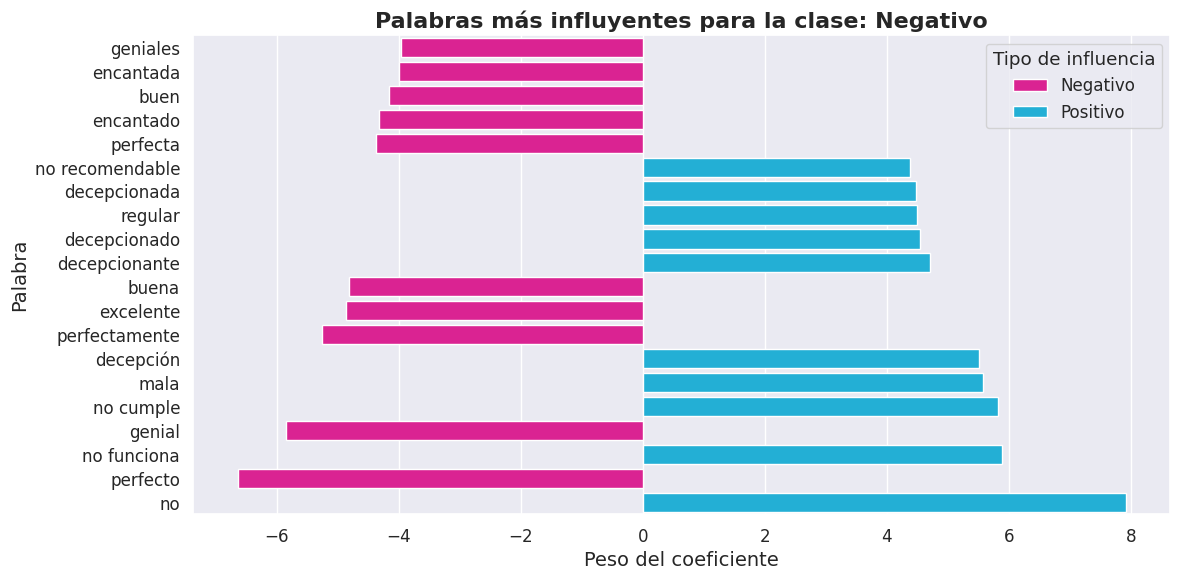

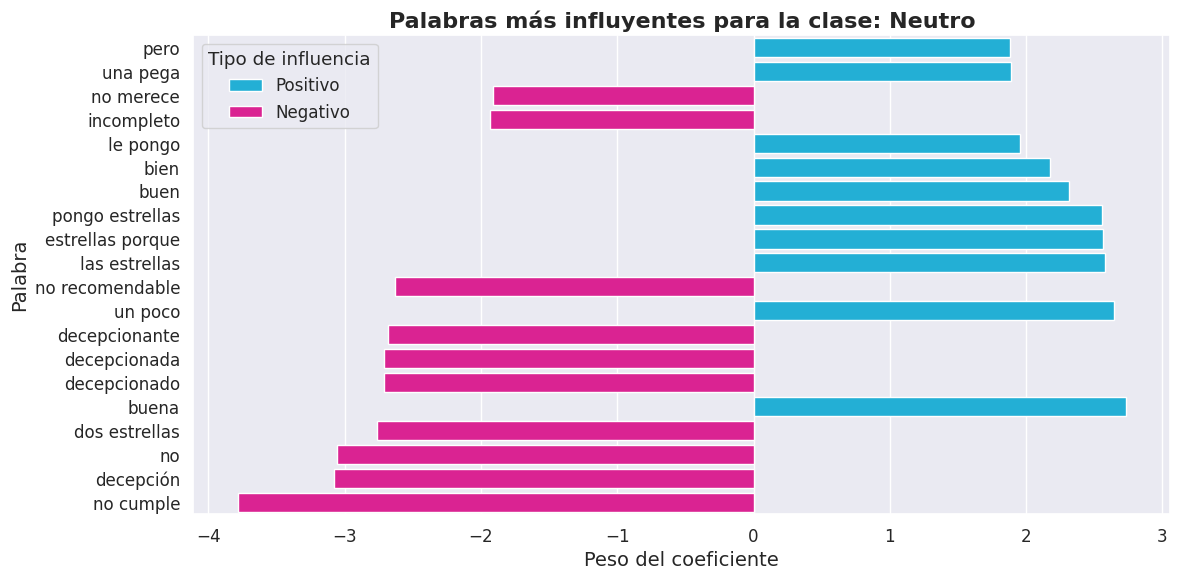

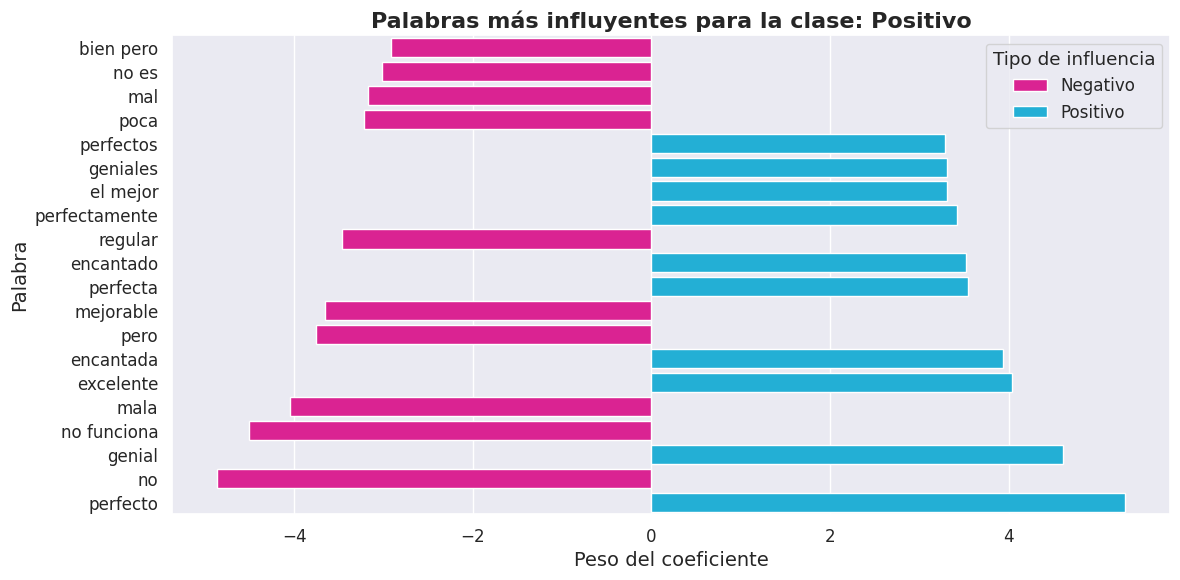

In [ ]:
for i, clase in enumerate(clases):
    top_pos, top_neg = top_palabras_por_clase(vectorizador, modelo, i)

    df_plot = pd.concat([top_pos, top_neg])

    # Ordenar por magnitud del coeficiente
    df_plot['abs_coef'] = df_plot['coeficiente'].abs()
    df_plot = df_plot.sort_values('abs_coef')

    # Identificar si el coeficiente es positivo o negativo
    df_plot['tipo_coef'] = df_plot['coeficiente'].apply(
        lambda x: 'Positivo' if x > 0 else 'Negativo'
    )

    # Paleta
    paleta_coef = {
        'Positivo': color_primario,
        'Negativo': color_secundario
    }

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_plot,
        x='coeficiente',
        y='palabra',
        hue='tipo_coef',
        palette=paleta_coef,
        dodge=False
    )

    plt.title(
        f'Palabras más influyentes para la clase: {clase}',
        fontsize=16,
        fontweight='bold'
    )
    plt.xlabel('Peso del coeficiente', fontsize=14)
    plt.ylabel('Palabra', fontsize=14)

    plt.legend(title='Tipo de influencia')
    plt.tight_layout()
    plt.show()

#### Análisis de Errores


In [ ]:
X_test

,text_limpio
0,no me llego no me llego el articulo me lo mand...
1,amazon sigue sin cumplir en las entregas la me...
2,estafa en el envío estoy muy decepcionado con ...
3,estafa de amazon mi valoración no es sobre el ...
4,no conseguí pasar de la portada en kindle pues...
...,...
4995,perfectos para lo que sirven para lo que cuest...
4996,buen vendedor rápido y fiable material muy fle...
4997,medallas con bonito grabado se ve bien el grabado
4998,timbre lo compré para mi bici pero finalmente ...


In [ ]:
datos_test = X_test.to_frame(name='text_limpio').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred


In [ ]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1257 de 5000


In [ ]:
errores.sample(10)

,text_limpio,real,prediccion
4375,buena calidad el abrigo cumple es caliente tie...,Positivo,Neutro
3631,buenísima calidad tal y como esperaba de nike ...,Neutro,Positivo
3736,perfecto sustituto a las bombillas incandescen...,Neutro,Positivo
4991,dinámico para bebes muy didáctico y es tal cua...,Positivo,Neutro
3113,el mejor en simbología y material de las carta...,Neutro,Positivo
2433,funda muy fina para cubrir sofá la funda para ...,Negativo,Neutro
3658,buen estado y perfecto viene todo perfecto con...,Neutro,Positivo
3415,carga bien recomendable buen producto carga bi...,Neutro,Positivo
3197,están muy bien buen tacto y buena presencia un...,Neutro,Positivo
3480,comodos y discretos fueron un regalo le quedan...,Neutro,Negativo


Errores de clasificación donde la clase real no coincide con la predicción. En un contexto multiclase, estos errores indican confusión entre sentimientos similares (por ejemplo, neutro vs positivo).

In [ ]:
for i, row in errores.head(10).iterrows():
    print(f"Review: {row['text_limpio'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")


Review: extremadamente cortos son tan cortos que apenas puedes enchufarlos pero como la medida venía en pulgadas no imaginé que fueran tan cortos ni me di cuenta de hacer la conversión mental a cms se adapta perfectamente a apple antiguo y android mini usb para usb c no sirve piensa que desde el enchufe a t...
Real: Negativo | Pred: Positivo

Review: perfectas para el postureo inservibles como gafas de sol si vas buscando unas gafas de sol que te protejan de los rayos uvno pierdas el tiempo éstas no son tus gafas ni protegen ni te dejan ver ya que los rayos solares reflejan en los cristales de las gafas incluso por la parte interior provocando t...
Real: Negativo | Pred: Neutro

Review: pieza de metal blando y barato bien podría tratarse de un trozo de tendedero arrancado es un material ligero y flexible viene con dos ganchos de plástico que se clavan a la pared levemente sin ninguna seguridad el precio es exagerado dada la descripción de materiales y elementos que lo componen...
Real:

##### Ejemplos de errores más frecuentes entre clases

In [ ]:
errores_frecuentes = (
    errores
    .groupby(['real', 'prediccion'])
    .size()
    .reset_index(name='cantidad')
    .sort_values('cantidad', ascending=False)
)

display(errores_frecuentes.head(10))

,real,prediccion,cantidad
0,Negativo,Neutro,432
3,Neutro,Positivo,306
5,Positivo,Neutro,241
2,Neutro,Negativo,145
1,Negativo,Positivo,79
4,Positivo,Negativo,54


#### Matriz de confusión


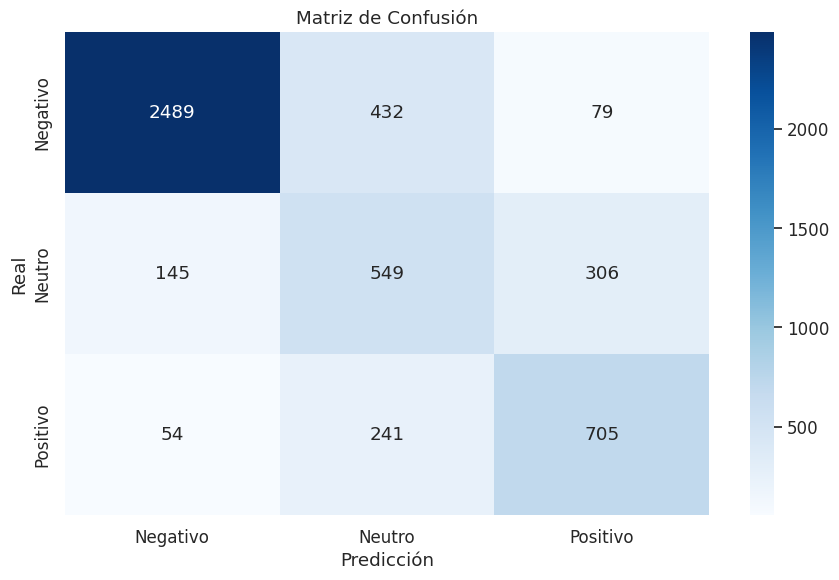

In [ ]:
labels = ['Negativo', 'Neutro', 'Positivo']

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = labels,
    yticklabels = labels
)

plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range = (1, 2),
        max_features = 5000,
        min_df = 5,
        max_df = 0.9,
        sublinear_tf = True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        n_jobs=-1,
        random_state=42
    ))
])

### **Reentrenar el pipeline con X y Y**

In [ ]:
X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])

In [ ]:
print(X.shape)
print(y.shape)

(204795,)
(204795,)


In [ ]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, random_state=42))])

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_ternario_1.0.joblib')

['sentiment_model_ternario_1.0.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: ['Negativo'], Probabilidad: 0.44


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`